In [1]:
!pip install pytrec_eval

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytrec_eval

In [3]:
BASE_DIR = os.getcwd()

In [4]:
BASE_DIR = "."
BLAST_PIDENT_PATH = os.path.join(BASE_DIR, "blast_pident.csv")

BLAST_ARCH_PATH = os.path.join(BASE_DIR, "blast_top50_arch.csv")
BLAST_EUK_PATH = os.path.join(BASE_DIR, "blast_top50_euk.csv")



KMER_ARCH_PATH = os.path.join(BASE_DIR, "kmer_k4_top50_arch.csv")
KMER_EUK_PATH = os.path.join(BASE_DIR, "kmer_k4_top50_euk.csv")

ESM_ARCH_PATH = os.path.join(BASE_DIR, "esm2_650m_top50_arch.csv")
ESM_EUK_PATH = os.path.join(BASE_DIR, "esm2_650m_top50_euk.csv")

OUTPUT_DIR = os.path.join(BASE_DIR, "twilight_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
from datasets import load_dataset
from collections import defaultdict

def load_qrels(qrels_path):
    qrels_ds = load_dataset(qrels_path)
    qrels = defaultdict(dict)

    for split in qrels_ds:
        for row in qrels_ds[split]:
            qrels[str(row["query_id"])][str(row["corpus_id"])] = 1

    return dict(qrels)

arch_qrels = load_qrels("tattabio/arch_retrieval_qrels")
euk_qrels = load_qrels("tattabio/euk_retrieval_qrels")

c:\Users\Shreya A\Downloads\690u project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def load_query_ids(dataset_path):
    ds = load_dataset(dataset_path)
    return [str(row["Entry"]) for row in ds["test"]]

arch_query_ids = load_query_ids("tattabio/arch_retrieval")
euk_query_ids = load_query_ids("tattabio/euk_retrieval")

In [7]:
def load_predictions(path):
    df = pd.read_csv(path)

    df["query_id"] = df["query_id"].astype(str)
    df["corpus_id"] = df["corpus_id"].astype(str)

    if "rank" in df.columns:
        df = df.sort_values(["query_id", "rank"])
    else:
        df = df.sort_values(["query_id"])

    pred = (
        df.groupby("query_id")["corpus_id"]
        .apply(lambda x: list(dict.fromkeys(x))[:50])
        .to_dict()
    )

    return pred

In [8]:
def pred_dict_to_list(query_ids, pred_dict):
    return [pred_dict.get(str(qid), []) for qid in query_ids]

In [9]:
def assign_bin(pident):
    if pident < 20:
        return "<20% Twilight"
    elif pident <= 40:
        return "20-40% Medium"
    else:
        return ">40% High"


def build_query_bins(blast_pident_path, query_ids, task):
    df = pd.read_csv(blast_pident_path)

    if "task" in df.columns:
        df = df[df["task"] == task]

    df["query_id"] = df["query_id"].astype(str)

    max_pident = (
        df.groupby("query_id")["pident"]
        .max()
        .to_dict()
    )

    rows = []

    for qid in query_ids:
        qid = str(qid)
        pident = float(max_pident.get(qid, 0.0))

        rows.append({
            "query_id": qid,
            "max_blast_pident": pident,
            "bin": assign_bin(pident)
        })

    return pd.DataFrame(rows)

In [10]:
def map5_pytrec(query_ids, retrieved_lists, qrels):
    run = {}

    for qid, retrieved in zip(query_ids, retrieved_lists):
        qid = str(qid)
        run[qid] = {}

        for rank, doc_id in enumerate(retrieved[:5]):
            run[qid][str(doc_id)] = float(5 - rank)

    evaluator = pytrec_eval.RelevanceEvaluator(
        qrels,
        {"map_cut.5"}
    )

    scores = evaluator.evaluate(run)

    valid_qids = [str(qid) for qid in query_ids if str(qid) in qrels]

    if not valid_qids:
        return np.nan, 0

    vals = [
        scores.get(qid, {}).get("map_cut_5", 0.0)
        for qid in valid_qids
    ]

    return float(np.mean(vals)), len(valid_qids)

In [11]:
BIN_ORDER = ["<20% Twilight", "20-40% Medium", ">40% High"]

def evaluate_by_bin(method_name, task_name, query_ids, pred_dict, qrels, bins_df):
    rows = []

    for bin_name in BIN_ORDER:
        bin_qids = (
            bins_df[bins_df["bin"] == bin_name]["query_id"]
            .astype(str)
            .tolist()
        )

        retrieved_lists = pred_dict_to_list(bin_qids, pred_dict)

        score, n = map5_pytrec(
            bin_qids,
            retrieved_lists,
            qrels
        )

        rows.append({
            "Task": task_name,
            "Method": method_name,
            "Bin": bin_name,
            "MAP@5": score,
            "n_queries": n
        })

    return pd.DataFrame(rows)

In [12]:
!python kmer_notebook.py


Loading Arch Retrieval ...

--- k = 2 ---
    Vocabulary size (k=2): 423
{'MAP@5': np.float64(0.01734), 'NDCG@5': np.float64(0.07919), 'Recall@5': np.float64(0.0241), 'P@5': np.float64(0.06965), 'MAP@10': np.float64(0.02072), 'NDCG@10': np.float64(0.0737), 'Recall@10': np.float64(0.03342), 'P@10': np.float64(0.05907), 'MAP@50': np.float64(0.02815), 'NDCG@50': np.float64(0.07083), 'Recall@50': np.float64(0.07409), 'P@50': np.float64(0.03719), 'MRR': np.float64(0.14205), 'n_queries': 2343}

--- k = 3 ---
    Vocabulary size (k=3): 8,046
{'MAP@5': np.float64(0.08662), 'NDCG@5': np.float64(0.30457), 'Recall@5': np.float64(0.09949), 'P@5': np.float64(0.26709), 'MAP@10': np.float64(0.10889), 'NDCG@10': np.float64(0.27875), 'Recall@10': np.float64(0.13417), 'P@10': np.float64(0.21912), 'MAP@50': np.float64(0.14863), 'NDCG@50': np.float64(0.24957), 'Recall@50': np.float64(0.2372), 'P@50': np.float64(0.10961), 'MRR': np.float64(0.42492), 'n_queries': 2343}

--- k = 4 ---
    Vocabulary size (k

In [19]:
blast_arch_pred = load_predictions(BLAST_ARCH_PATH)
blast_euk_pred = load_predictions(BLAST_EUK_PATH)

kmer_arch_pred = load_predictions(KMER_ARCH_PATH)
kmer_euk_pred = load_predictions(KMER_EUK_PATH)


esm_arch_path = os.path.join(BASE_DIR, "esm2_650M_middle_top50_arch.csv")
esm_euk_path = os.path.join(BASE_DIR, "esm2_650M_middle_top50_euk.csv")
esm_arch_pred = load_predictions(esm_arch_path)
esm_euk_pred = load_predictions(esm_euk_path)

In [20]:
arch_bins = build_query_bins(
    BLAST_PIDENT_PATH,
    arch_query_ids,
    task="arch"
)

euk_bins = build_query_bins(
    BLAST_PIDENT_PATH,
    euk_query_ids,
    task="euk"
)

print("Arch bins:")
display(arch_bins["bin"].value_counts())

print("Euk bins:")
display(euk_bins["bin"].value_counts())

Arch bins:


bin
>40% High        2006
20-40% Medium     337
Name: count, dtype: int64

Euk bins:


bin
>40% High        262
20-40% Medium     49
Name: count, dtype: int64

In [21]:
rows = []

rows.append(
    evaluate_by_bin(
        "BLASTP",
        "Arch Retrieval",
        arch_query_ids,
        blast_arch_pred,
        arch_qrels,
        arch_bins
    )
)

rows.append(
    evaluate_by_bin(
        "k-mer k=4",
        "Arch Retrieval",
        arch_query_ids,
        kmer_arch_pred,
        arch_qrels,
        arch_bins
    )
)

rows.append(
    evaluate_by_bin(
        "ESM2-650M",
        "Arch Retrieval",
        arch_query_ids,
        esm_arch_pred,
        arch_qrels,
        arch_bins
    )
)

rows.append(
    evaluate_by_bin(
        "BLASTP",
        "Euk Retrieval",
        euk_query_ids,
        blast_euk_pred,
        euk_qrels,
        euk_bins
    )
)

rows.append(
    evaluate_by_bin(
        "k-mer k=4",
        "Euk Retrieval",
        euk_query_ids,
        kmer_euk_pred,
        euk_qrels,
        euk_bins
    )
)

rows.append(
    evaluate_by_bin(
        "ESM2-650M",
        "Euk Retrieval",
        euk_query_ids,
        esm_euk_pred,
        euk_qrels,
        euk_bins
    )
)

df_twilight = pd.concat(rows, ignore_index=True)

display(df_twilight)

df_twilight.to_csv(
    os.path.join(OUTPUT_DIR, "twilight_zone_results.csv"),
    index=False
)

,Task,Method,Bin,MAP@5,n_queries
0,Arch Retrieval,BLASTP,<20% Twilight,NaN,0
1,Arch Retrieval,BLASTP,20-40% Medium,0.273027,337
2,Arch Retrieval,BLASTP,>40% High,0.303022,2006
3,Arch Retrieval,k-mer k=4,<20% Twilight,NaN,0
4,Arch Retrieval,k-mer k=4,20-40% Medium,0.085051,337
5,Arch Retrieval,k-mer k=4,>40% High,0.198996,2006
6,Arch Retrieval,ESM2-650M,<20% Twilight,NaN,0
7,Arch Retrieval,ESM2-650M,20-40% Medium,0.294134,337
8,Arch Retrieval,ESM2-650M,>40% High,0.317254,2006
9,Euk Retrieval,BLASTP,<20% Twilight,NaN,0


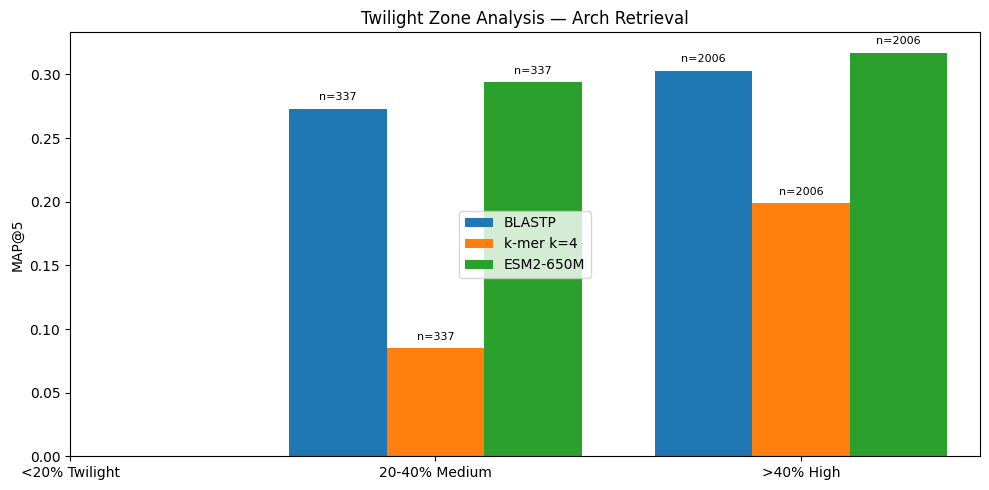

Saved: .\twilight_outputs\twilight_arch_retrieval.png


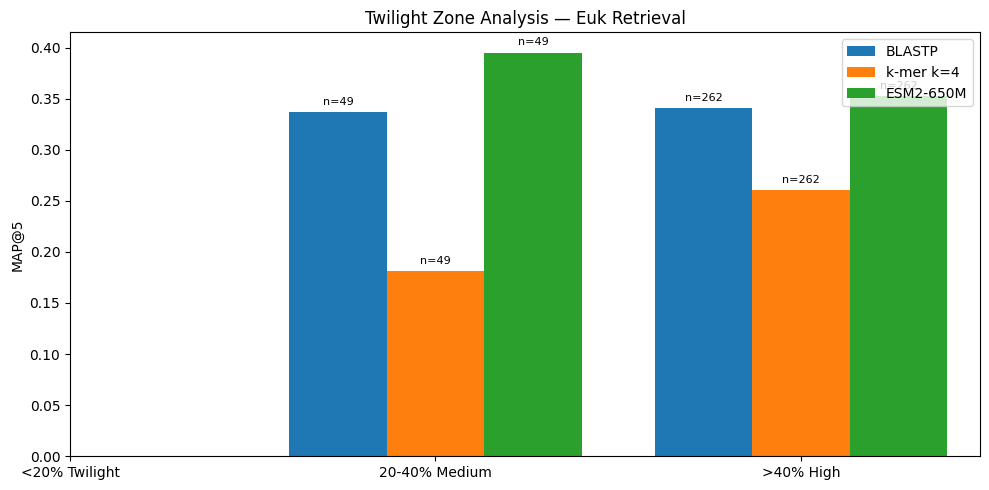

Saved: .\twilight_outputs\twilight_euk_retrieval.png


In [22]:
def plot_twilight(df, task_name):
    plot_df = df[df["Task"] == task_name].copy()

    methods = plot_df["Method"].unique()
    x = np.arange(len(BIN_ORDER))
    width = 0.8 / len(methods)

    plt.figure(figsize=(10, 5))

    for i, method in enumerate(methods):
        temp = plot_df[plot_df["Method"] == method].set_index("Bin")

        scores = [
            temp.loc[b, "MAP@5"] if b in temp.index else np.nan
            for b in BIN_ORDER
        ]

        ns = [
            temp.loc[b, "n_queries"] if b in temp.index else 0
            for b in BIN_ORDER
        ]

        offset = (i - (len(methods) - 1) / 2) * width

        bars = plt.bar(
            x + offset,
            scores,
            width,
            label=method
        )

        for bar, score, n in zip(bars, scores, ns):
            if not np.isnan(score):
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"n={int(n)}",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

    plt.xticks(x, BIN_ORDER)
    plt.ylabel("MAP@5")
    plt.title(f"Twilight Zone Analysis — {task_name}")
    plt.legend()
    plt.tight_layout()

    output_path = os.path.join(
        OUTPUT_DIR,
        f"twilight_{task_name.lower().replace(' ', '_')}.png"
    )

    plt.savefig(output_path, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


plot_twilight(df_twilight, "Arch Retrieval")
plot_twilight(df_twilight, "Euk Retrieval")